# Analyze TRISHNA grid

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

In [3]:
from evaspa import tiling, trishna

### Read TRISHNA grid

In [4]:
trishna_grid = trishna.get_trishna_tiles()

In [5]:
trishna_grid.head()

,id,utm_zone,epsg,ulx,uly,misscover,geometry
0,01CDP,1,32701,399960.0,1400020.0,0.669118,"MULTIPOLYGON (((-179.99622 -77.46018, -178.864..."
1,01CDQ,1,32701,399960.0,1500040.0,0.377010,"MULTIPOLYGON (((-179.7998 -76.56503, -178.7418..."
2,01CEP,1,32701,499980.0,1400020.0,0.806809,"POLYGON ((-177.00083 -77.47679, -177.00083 -77..."
3,01CEQ,1,32701,499980.0,1500040.0,0.227079,"POLYGON ((-177.00077 -76.58049, -177.00077 -76..."
4,01FBE,1,32701,199980.0,4500040.0,0.848541,"MULTIPOLYGON (((-179.63379 -49.62222, -179.647..."


### Read land mask

In [6]:
land = trishna.get_land_mask()

In [7]:
land.head()

,id,level,source,parent_id,sibling_id,area,geometry
0,0-E,1,WVS,-1,0,5.065405e+07,"POLYGON ((180 68.99378, 180 65.03262, 179.8598..."
1,0-W,1,WVS,-1,0,5.065405e+07,"POLYGON ((-180 68.99378, -179.99844 68.99292, ..."
2,1,1,WVS,-1,1,2.922097e+07,"POLYGON ((32.29356 31.21186, 32.2845 31.23281,..."
3,2,1,WVS,-1,2,2.015474e+07,"POLYGON ((-79.95222 9.31825, -79.92538 9.3124,..."
4,3,1,WVS,-1,3,1.753416e+07,"POLYGON ((-73.36172 -53.00042, -73.36261 -53, ..."


### Read orbits 

In [8]:
orbits = trishna.get_trishna_orbits()

In [9]:
orbits.head()

,orbit_id,geometry
0,0,"MULTIPOLYGON (((-102.64823 77.79477, -110.7057..."
1,1,"MULTIPOLYGON (((-127.69193 77.79485, -135.7494..."
2,2,"MULTIPOLYGON (((-152.73563 77.79493, -160.7932..."
3,3,"MULTIPOLYGON (((-177.8314 77.79347, -178.27292..."
4,4,"POLYGON ((157.17697 77.79509, 149.11924 77.370..."


### Compute land percentage per tile

In [10]:
land_trishna_tiles = tiling.intersection(trishna_grid, land)

In [11]:
len(land_trishna_tiles)

18708

### Plot

<Axes: xlabel='Land surface percentage', ylabel='Number of TRISHNA tiles'>

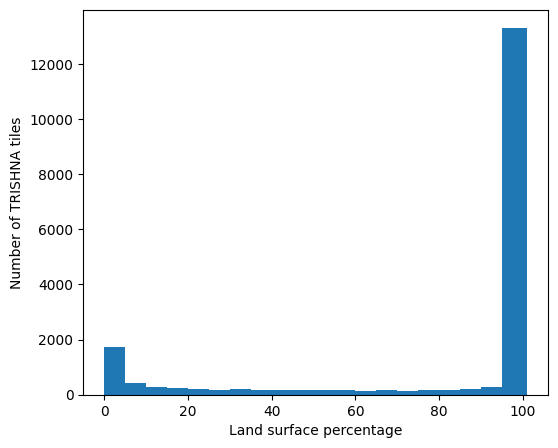

In [12]:
bins = np.arange(0, 101, 5)
bins[-1] = 101
land_trishna_tiles.plot.hist(
    column=["overlap_percentage"],
    bins=bins,
    figsize=(6, 5),
    legend=False,
    xlabel="Land surface percentage",
    ylabel="Number of TRISHNA tiles",
)

In [13]:
out, _ = pd.cut(
    land_trishna_tiles["overlap_percentage"],
    bins=bins,
    include_lowest=True,
    right=False,
    retbins=True,
)
count = out.value_counts()
print(count.index[0], count.values[0])
print(count.index[1], count.values[1])
print("rest", count.values[2:].sum())

[95, 101) 13294
[0, 5) 1722
rest 3692
